In [ ]:
# 05 — Comparaison des modèles (Aicha)

Objectif : comparer les modèles KNN (Aya), Arbre de décision (Malak) et SVM (Malak)
sur le même dataset et le même découpage train/test défini par Adam, puis choisir le modèle final
en se basant sur les métriques d’évaluation et la généralisation (overfitting/underfitting).


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [3]:
df = pd.read_csv("../data/energy_dataset.csv")
df.head()


,surface_area,wall_area,roof_area,glazing_area,height,compactness,orientation,energy_class
0,274,378,272,19,4.702751,0.530007,4,1
1,339,359,175,18,4.972581,0.817926,1,0
2,314,297,140,17,3.809120,0.644334,2,0
3,332,448,170,17,5.141293,0.680344,4,0
4,313,342,260,28,4.652013,0.756585,2,1


In [4]:
X = df.drop(columns=["energy_class"])
y = df["energy_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((4000, 7), (1000, 7))

In [7]:
def metrics_macro(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title(title)
    plt.show()
    return cm


In [ ]:
## Modèle 1 : KNN (Aya)

KNN utilise des distances, donc on standardise les variables (StandardScaler).
Hyperparamètres choisis par Aya :
- k = 9
- p = 1
- weights = "distance"


In [9]:
# Définition explicite des classes (obligatoire pour la matrice de confusion)
labels = sorted(y.unique())
labels


[np.int64(0), np.int64(1), np.int64(2)]

=== KNN (TEST) ===
{'accuracy': 0.839, 'precision': 0.7333422597505476, 'recall': 0.6244656403972649, 'f1': 0.6326980412218998}

=== KNN classification_report (TEST) ===
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       569
           1       0.75      0.85      0.80       371
           2       0.54      0.12      0.19        60

    accuracy                           0.84      1000
   macro avg       0.73      0.62      0.63      1000
weighted avg       0.83      0.84      0.82      1000



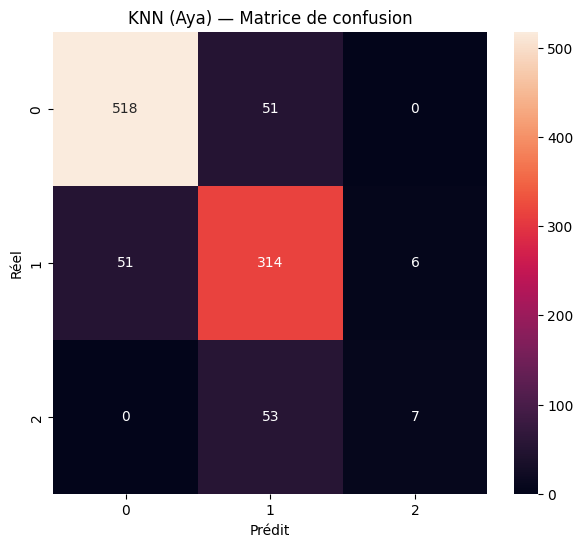

array([[518,  51,   0],
       [ 51, 314,   6],
       [  0,  53,   7]])

In [10]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=9, p=1, weights="distance"))
])

knn_model.fit(X_train, y_train)

knn_pred_test = knn_model.predict(X_test)
knn_pred_train = knn_model.predict(X_train)

print("=== KNN (TEST) ===")
print(metrics_macro(y_test, knn_pred_test))

print("\n=== KNN classification_report (TEST) ===")
print(classification_report(y_test, knn_pred_test, zero_division=0))

show_confusion(y_test, knn_pred_test, "KNN (Aya) — Matrice de confusion")


In [ ]:
## Modèle 2 : Arbre de décision (Malak)

L’arbre peut sur-apprendre s’il est trop profond.
Malak a appliqué l’élagage en limitant la profondeur :
- max_depth = 4


=== Decision Tree (TEST) ===
{'accuracy': 0.851, 'precision': 0.7535154760174896, 'recall': 0.7517070452989145, 'f1': 0.7513887474807014}

=== Decision Tree classification_report (TEST) ===
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       569
           1       0.77      0.85      0.81       371
           2       0.54      0.52      0.53        60

    accuracy                           0.85      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.86      0.85      0.85      1000



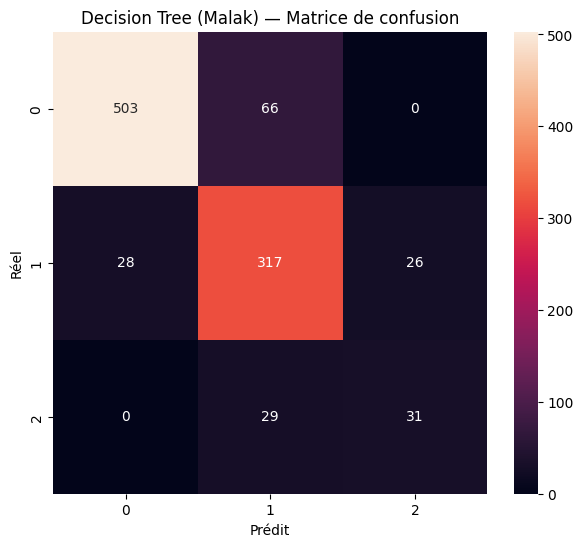

array([[503,  66,   0],
       [ 28, 317,  26],
       [  0,  29,  31]])

In [11]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred_test = tree_model.predict(X_test)
tree_pred_train = tree_model.predict(X_train)

print("=== Decision Tree (TEST) ===")
print(metrics_macro(y_test, tree_pred_test))

print("\n=== Decision Tree classification_report (TEST) ===")
print(classification_report(y_test, tree_pred_test, zero_division=0))

show_confusion(y_test, tree_pred_test, "Decision Tree (Malak) — Matrice de confusion")


In [ ]:
## Modèle 3 : SVM (Malak)

SVM dépend aussi des échelles, donc on standardise.
Le meilleur modèle trouvé : SVM linéaire
- kernel = "linear"
- C = 10


=== SVM (TEST) ===
{'accuracy': 0.869, 'precision': 0.7897608891323915, 'recall': 0.7538756433921736, 'f1': 0.7679880613922344}

=== SVM classification_report (TEST) ===
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       569
           1       0.80      0.87      0.83       371
           2       0.63      0.48      0.55        60

    accuracy                           0.87      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.87      0.87      0.87      1000



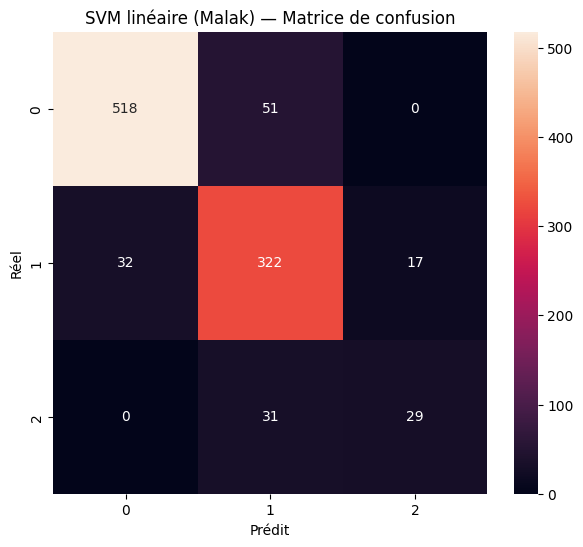

array([[518,  51,   0],
       [ 32, 322,  17],
       [  0,  31,  29]])

In [12]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=10))
])

svm_model.fit(X_train, y_train)

svm_pred_test = svm_model.predict(X_test)
svm_pred_train = svm_model.predict(X_train)

print("=== SVM (TEST) ===")
print(metrics_macro(y_test, svm_pred_test))

print("\n=== SVM classification_report (TEST) ===")
print(classification_report(y_test, svm_pred_test, zero_division=0))

show_confusion(y_test, svm_pred_test, "SVM linéaire (Malak) — Matrice de confusion")


In [13]:
knn_train_m = metrics_macro(y_train, knn_pred_train)
tree_train_m = metrics_macro(y_train, tree_pred_train)
svm_train_m = metrics_macro(y_train, svm_pred_train)

print("=== Généralisation (F1 macro) ===")
print("KNN : train =", knn_train_m["f1"], " test =", metrics_macro(y_test, knn_pred_test)["f1"], " gap =", knn_train_m["f1"] - metrics_macro(y_test, knn_pred_test)["f1"])
print("Tree: train =", tree_train_m["f1"], " test =", metrics_macro(y_test, tree_pred_test)["f1"], " gap =", tree_train_m["f1"] - metrics_macro(y_test, tree_pred_test)["f1"])
print("SVM : train =", svm_train_m["f1"], " test =", metrics_macro(y_test, svm_pred_test)["f1"], " gap =", svm_train_m["f1"] - metrics_macro(y_test, svm_pred_test)["f1"])


=== Généralisation (F1 macro) ===
KNN : train = 1.0  test = 0.6326980412218998  gap = 0.36730195877810023
Tree: train = 0.7804797418266611  test = 0.7513887474807014  gap = 0.029090994345959742
SVM : train = 0.782742210092663  test = 0.7679880613922344  gap = 0.014754148700428571


In [14]:
knn_test_m = metrics_macro(y_test, knn_pred_test)
tree_test_m = metrics_macro(y_test, tree_pred_test)
svm_test_m = metrics_macro(y_test, svm_pred_test)

compare = pd.DataFrame([
    {"Model":"KNN (Aya)", "Hyperparams":"k=9, p=1, weights=distance", **knn_test_m},
    {"Model":"Decision Tree (Malak)", "Hyperparams":"max_depth=4", **tree_test_m},
    {"Model":"SVM linéaire (Malak)", "Hyperparams":"kernel=linear, C=10", **svm_test_m},
]).sort_values(by="f1", ascending=False)

compare


,Model,Hyperparams,accuracy,precision,recall,f1
2,SVM linéaire (Malak),"kernel=linear, C=10",0.869,0.789761,0.753876,0.767988
1,Decision Tree (Malak),max_depth=4,0.851,0.753515,0.751707,0.751389
0,KNN (Aya),"k=9, p=1, weights=distance",0.839,0.733342,0.624466,0.632698


In [ ]:
## Choix du modèle final

On choisit le modèle qui donne :
- de bonnes métriques (accuracy, precision, recall, F1)
- une bonne généralisation (écart train/test raisonnable)
- des erreurs acceptables selon la matrice de confusion (classe par classe)


In [ ]:
Le modèle SVM linéaire a été retenu comme modèle final car il présente le meilleur compromis entre performance et capacité de généralisation.
Il obtient les meilleurs scores en termes de F1-score macro tout en maintenant un écart réduit entre les performances sur les données d’entraînement et de test, ce qui indique une bonne généralisation.
Contrairement au KNN, il est moins sensible au déséquilibre des classes, et contrairement à l’arbre de décision, il limite le risque de surapprentissage grâce au paramètre de régularisation C.